In [120]:
import gfapy
import networkx as nx
import numpy as np
from dimod import CQM, Binary, BQM
import re

In [121]:
def invert_orient(orient: str):
    if orient == '+':
        return '-'
    elif orient == '-':
        return '+'
    else:
        raise Exception('Bad orient')

In [122]:
def oriented_graph_from_file(filename):
    """Reads a .gfa file into the dual graph.

    Args:
        filename (str): filepath to read.

    Returns:
        nx.Graph: corresponding oriented graph.
    """
    gfa = gfapy.Gfa.from_file(filename, vlevel=0)
    graph = nx.DiGraph()
    for edge_line in gfa.edges:
        v1 = edge_line.sid1
        v2 = edge_line.sid2
        forward_node = f'{v1.name}{v1.orient}_{v2.name}{v2.orient}'
        graph.add_node(forward_node, weight=edge_line.EC)
        backward_node = f'{v2.name}{invert_orient(v2.orient)}_{v1.name}{invert_orient(v1.orient)}'
        graph.add_node(backward_node, weight=edge_line.EC)
        for node in graph.nodes:
            node_matches = re.search(
                r'(.+[\+\-])_(.+[\+\-])',
                node
            )
            node_start = node_matches.group(1)
            node_end = node_matches.group(2)
            if node_start == f'{v2.name}{v2.orient}':
                graph.add_edges_from([(forward_node, node)])
            if node_start == f'{v1.name}{invert_orient(v1.orient)}':
                graph.add_edges_from([(backward_node, node)])
            if node_end == f'{v1.name}{v1.orient}':
                graph.add_edges_from([(node, forward_node)])
            if node_end == f'{v2.name}{invert_orient(v2.orient)}':
                graph.add_edges_from([(node, backward_node)])
                
    return graph

In [123]:
def normalise_node_weights(graph, normalisation):
    for node in graph.nodes:
        graph.nodes[node]["weight"] = round(graph.nodes[node]["weight"] / normalisation)
    return graph

In [124]:
# g = oriented_graph_from_file('../../data/test.gfa')
g = oriented_graph_from_file('../../data/ddDapMeze1.MT.k101.utg.final.gfa')
g = normalise_node_weights(g, 100)

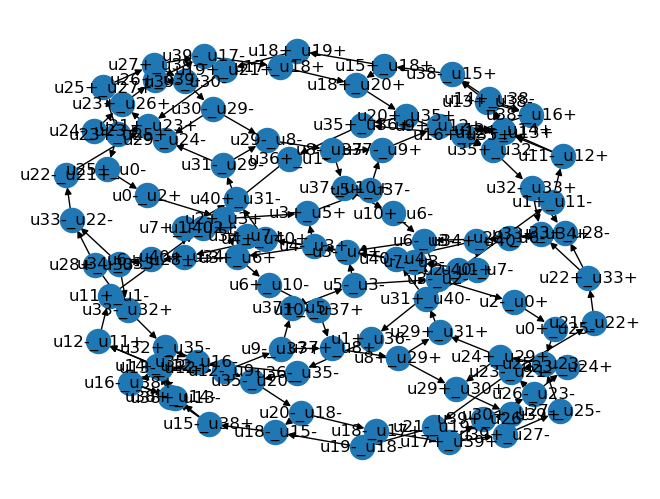

In [125]:
nx.draw_kamada_kawai(g, with_labels=True)

In [126]:
nodes = list(g.nodes)
V = int(len(nodes))
total_weight = int(sum(g.nodes[node]["weight"] for node in nodes) / 2)
alpha = 1.2
T_max = int(total_weight * alpha)

lambda_g = 2
lambda_w = 4

In [127]:
def array_to_path(arr):
    nz = np.nonzero(arr == 1)
    return [(nz[0][i], nodes[nz[1][i]] if nz[1][i] in range(V) else 'end') for i in range(nz[0].shape[0])]
        

In [128]:
variables_array_shape = (T_max, V + 1)
def var_index(multi_index):
    return np.ravel_multi_index(multi_index, variables_array_shape)

In [129]:
cqm = CQM()
variables = [Binary(i) for i in range(T_max * (V+1))]
obj = lambda_w * sum(
    (g.nodes[nodes[i]]["weight"] - sum(variables[var_index((t, i))] + variables[var_index((t, i + 1))] for t in range(T_max))) ** 2
    for i in range(0, V, 2)
) + 0 * sum(variables)
obj = cqm.set_objective(obj)

In [131]:
# Graph constraints
g_constraints = []
for i in range(V):
    for j in range(V):
        if not (nodes[i], nodes[j]) in g.edges:
            g_constraints.append(cqm.add_constraint_from_iterable(
                [(var_index((t, i)), var_index((t + 1, j)), 1) for t in range(T_max - 1)],
                sense='==',
                rhs=0,
                label=f'g_{i}_{j}',
            ))

# Path constraints
t_constraints = []
for t in range(T_max):
    t_constraints.append(cqm.add_constraint_from_iterable(
        [(var_index((t, i)), 1) for i in range(V)] + [(var_index((t, V)), 1)],
        sense='==',
        rhs=1,
        label=f't_{t}'
    ))

# Don't leave end constraints
end_constraints = []
for t in range(T_max - 1):
    end_constraints.append(cqm.add_constraint_from_iterable(
        [(var_index((t, V)), var_index((t + 1, i)), 1) for i in range(V)],
        sense='==',
        rhs=0,
        label=f'end_{t}'
    ))


NotImplementedError: 

In [ ]:
print(cqm.constraint_labels)

Variables(['g_0_0', 'g_0_1', 'g_0_2', 'g_0_3', 'g_0_4', 'g_0_5', 'g_0_7', 'g_0_8', 'g_0_9', 'g_0_10', 'g_0_11', 'g_0_12', 'g_0_13', 'g_0_14', 'g_0_15', 'g_0_16', 'g_0_17', 'g_0_18', 'g_0_19', 'g_0_20', 'g_0_21', 'g_0_22', 'g_0_23', 'g_0_24', 'g_0_25', 'g_0_26', 'g_0_27', 'g_0_28', 'g_0_29', 'g_0_30', 'g_0_31', 'g_0_32', 'g_0_33', 'g_0_34', 'g_0_35', 'g_0_36', 'g_0_37', 'g_0_38', 'g_0_39', 'g_0_40', 'g_0_41', 'g_0_42', 'g_0_43', 'g_0_44', 'g_0_45', 'g_0_46', 'g_0_47', 'g_0_48', 'g_0_49', 'g_0_50', 'g_0_51', 'g_0_52', 'g_0_53', 'g_0_54', 'g_0_55', 'g_0_56', 'g_0_57', 'g_0_58', 'g_0_59', 'g_0_60', 'g_0_61', 'g_0_62', 'g_0_63', 'g_0_64', 'g_0_65', 'g_0_66', 'g_0_67', 'g_0_68', 'g_0_69', 'g_0_70', 'g_0_71', 'g_0_72', 'g_0_73', 'g_0_74', 'g_0_75', 'g_0_76', 'g_0_77', 'g_0_78', 'g_0_79', 'g_0_80', 'g_0_81', 'g_0_82', 'g_0_83', 'g_0_84', 'g_0_85', 'g_0_86', 'g_0_87', 'g_0_88', 'g_0_89', 'g_0_90', 'g_0_91', 'g_0_92', 'g_0_93', 'g_0_94', 'g_0_95', 'g_0_96', 'g_0_97', 'g_0_98', 'g_0_99', 'g_0_100

In [ ]:
print(cqm.variables)
print(cqm.num_biases())

Variables([0, 1, 111, 112, 222, 223, 333, 334, 444, 445, 555, 556, 666, 667, 777, 778, 888, 889, 999, 1000, 1110, 1111, 1221, 1222, 1332, 1333, 1443, 1444, 1554, 1555, 1665, 1666, 1776, 1777, 1887, 1888, 1998, 1999, 2109, 2110, 2220, 2221, 2331, 2332, 2442, 2443, 2553, 2554, 2664, 2665, 2775, 2776, 2886, 2887, 2997, 2998, 3108, 3109, 3219, 3220, 3330, 3331, 3441, 3442, 3552, 3553, 3663, 3664, 3774, 3775, 3885, 3886, 3996, 3997, 4107, 4108, 4218, 4219, 4329, 4330, 4440, 4441, 4551, 4552, 4662, 4663, 4773, 4774, 4884, 4885, 4995, 4996, 5106, 5107, 5217, 5218, 5328, 5329, 5439, 5440, 5550, 5551, 5661, 5662, 5772, 5773, 5883, 5884, 5994, 5995, 6105, 6106, 6216, 6217, 6327, 6328, 6438, 6439, 6549, 6550, 6660, 6661, 6771, 6772, 6882, 6883, 6993, 6994, 7104, 7105, 7215, 7216, 7326, 7327, 7437, 7438, 7548, 7549, 7659, 7660, 7770, 7771, 7881, 7882, 7992, 7993, 2, 3, 113, 114, 224, 225, 335, 336, 446, 447, 557, 558, 668, 669, 779, 780, 890, 891, 1001, 1002, 1112, 1113, 1223, 1224, 1334, 1335, 14

In [ ]:
cqm.constraints[g_constraints[0]].to_polystring()
# cqm.objective.to_polystring()

'v111*v0 + v111*v222 + v222*v333 + v333*v444 + v444*v555 + v555*v666 + v666*v777 + v777*v888 + v888*v999 + v999*v1110 + v1110*v1221 + v1221*v1332 + v1332*v1443 + v1443*v1554 + v1554*v1665 + v1665*v1776 + v1776*v1887 + v1887*v1998 + v1998*v2109 + v2109*v2220 + v2220*v2331 + v2331*v2442 + v2442*v2553 + v2553*v2664 + v2664*v2775 + v2775*v2886 + v2886*v2997 + v2997*v3108 + v3108*v3219 + v3219*v3330 + v3330*v3441 + v3441*v3552 + v3552*v3663 + v3663*v3774 + v3774*v3885 + v3885*v3996 + v3996*v4107 + v4107*v4218 + v4218*v4329 + v4329*v4440 + v4440*v4551 + v4551*v4662 + v4662*v4773 + v4773*v4884 + v4884*v4995 + v4995*v5106 + v5106*v5217 + v5217*v5328 + v5328*v5439 + v5439*v5550 + v5550*v5661 + v5661*v5772 + v5772*v5883 + v5883*v5994 + v5994*v6105 + v6105*v6216 + v6216*v6327 + v6327*v6438 + v6438*v6549 + v6549*v6660 + v6660*v6771 + v6771*v6882 + v6882*v6993 + v6993*v7104 + v7104*v7215 + v7215*v7326 + v7326*v7437 + v7437*v7548 + v7548*v7659 + v7659*v7770 + v7770*v7881 + v7881*v7992 == 0.0'

In [ ]:
from dwave.system import LeapHybridCQMSampler
sampler = LeapHybridCQMSampler()  

In [70]:
sampleset = sampler.sample_cqm(cqm, time_limit=30, label="CQM Edge Test k101")  
print("{} feasible solutions of {}.".format(sampleset.record.is_feasible.sum(), len(sampleset))) 

0 feasible solutions of 98.


In [108]:
def sample_to_path(sample):
    path = []
    for key, val in sample.items():
        if val == 1.0:
            multi_index = np.unravel_index(key, (T_max, V+1))
            path.append((multi_index[0], nodes[multi_index[1]] if multi_index[1] < V else 'end'))
    return path

In [109]:
# best = sampleset.filter(lambda row: row.is_feasible).first
best = sampleset.first
path = sample_to_path(best.sample)
print(best.energy)
for p in path:
    print(p)


52.0
(0, 'u40+_u31-')
(1, 'u20-_u18-')
(2, 'u18-_u15-')
(3, 'u15-_u38+')
(4, 'u38+_u13-')
(5, 'u13-_u12-')
(6, 'u12-_u11+')
(7, 'u11+_u1-')
(8, 'u1-_u2+')
(9, 'u2+_u3+')
(10, 'u3+_u6+')
(11, 'u6+_u28+')
(12, 'u28+_u33-')
(13, 'u33-_u22-')
(14, 'u22-_u21+')
(15, 'u21+_u23+')
(16, 'u25+_u0-')
(17, 'u37+_u5-')
(18, 'end')
(19, 'end')
(20, 'end')
(21, 'end')
(22, 'end')
(24, 'u32+_u35-')
(25, 'u35-_u16-')
(26, 'u16-_u38+')
(27, 'u38+_u14-')
(28, 'u2-_u0+')
(29, 'u3+_u7+')
(30, 'u7+_u40+')
(31, 'u3+_u5+')
(32, 'u34+_u40-')
(33, 'end')
(34, 'end')
(35, 'end')
(36, 'end')
(37, 'end')
(38, 'end')
(39, 'end')
(40, 'end')
(41, 'end')
(42, 'end')
(44, 'u8+_u29+')
(45, 'u29+_u30+')
(46, 'u30+_u39+')
(47, 'u39+_u27-')
(48, 'u27-_u25-')
(49, 'u25-_u23-')
(50, 'u23-_u24+')
(51, 'u24+_u29+')
(52, 'u29+_u30+')
(53, 'u1+_u36-')
(54, 'u23+_u26+')
(55, 'u26+_u39-')
(56, 'u39-_u17-')
(57, 'u17-_u18+')
(58, 'u18+_u20+')
(59, 'u20+_u35+')
(60, 'u3-_u4+')
(61, 'u37-_u9+')
(62, 'u9+_u12+')
(63, 'u12-_u9-')
(64

In [119]:
for v in cqm.iter_violations(sampleset.record[4][0], skip_satisfied=True):
    print(v)

('g_2_75', 1.0)
('g_3_103', 1.0)
('g_4_108', 1.0)
('g_12_4', 1.0)
('g_17_64', 1.0)
('g_18_65', 1.0)
('g_21_6', 1.0)
('g_27_63', 1.0)
('g_29_67', 1.0)
('g_41_71', 1.0)
('g_46_3', 1.0)
('g_51_46', 1.0)
('g_52_41', 1.0)
('g_56_11', 1.0)
('g_59_9', 1.0)
('g_63_17', 1.0)
('g_65_42', 1.0)
('g_67_87', 1.0)
('g_69_56', 1.0)
('g_75_101', 1.0)
('g_81_21', 1.0)
('g_90_59', 1.0)
('g_101_91', 1.0)


In [151]:
sample_values = list(best.sample.values())

In [152]:
lambda_w * sum(
    (g.nodes[nodes[i]]["weight"] - sum(sample_values[var_index((t, i))] + sample_values[var_index((t, i + 1))] for t in range(T_max))) ** 2
    for i in range(0, V, 2)
)

0.0

In [153]:
- lambda_g * sum(
    sample_values[var_index((t, nodes.index(e[0])))] * sample_values[var_index((t + 1, nodes.index(e[1])))] for e in g.edges for t in range(T_max - 1)
)

-104.0

In [154]:
- (lambda_g - 1) * sum(
    sum(sample_values[var_index((t, i))] * sample_values[var_index((t + 1, V))] for i in range(V))
    + sample_values[var_index((t, V))] * sample_values[var_index((t + 1, V))]
    for t in range(T_max - 1) 
)

-12.0

In [13]:
# k501 path
# best_path_nodes = ['u5-','u3-','u0-','u2+','u9+','u6-','u5+','u4-','u0-','u2+','u9+','u11+','u15+','u16+','u14-','u13-','u12+','u11-','u9-','u2-','u1+','u13-','u10-','u9-','u8+','u16-','u7-', 'u5-']

# k101 path
best_path_nodes = ["u21+","u23+","u25+","u27+","u39-","u30-","u29-","u24-","u23+","u25+","u0-","u2+","u3+","u6+","u10-","u37+","u5-","u3-","u2-","u1+","u11-","u12+","u14+","u38-","u16+","u35+","u32-","u33+","u34+","u40-","u7-","u3-","u2-","u1+","u36-","u35-","u20-","u18-","u17+","u39+","u26-","u23-","u21-","u19-","u18-","u15-","u38+","u13-","u12-","u9-","u37+","u8+","u29+","u31+","u40-","u4-","u3+","u6+","u28+","u33-","u22-", "u21+"]


best_path = [f'{best_path_nodes[i]}_{best_path_nodes[i+1]}' for i in range(len(best_path_nodes) - 1)]
best_path_sample = np.zeros((T_max, V+1))
for t in range(len(best_path)):
    best_path_sample[t, nodes.index(best_path[t])] = 1
best_path_sample[t+1:, -1] = 1
print(array_to_path(best_path_sample))
best_path_list = best_path_sample.reshape((T_max * (V+1),))


[(0, 'u21+_u23+'), (1, 'u23+_u25+'), (2, 'u25+_u27+'), (3, 'u27+_u39-'), (4, 'u39-_u30-'), (5, 'u30-_u29-'), (6, 'u29-_u24-'), (7, 'u24-_u23+'), (8, 'u23+_u25+'), (9, 'u25+_u0-'), (10, 'u0-_u2+'), (11, 'u2+_u3+'), (12, 'u3+_u6+'), (13, 'u6+_u10-'), (14, 'u10-_u37+'), (15, 'u37+_u5-'), (16, 'u5-_u3-'), (17, 'u3-_u2-'), (18, 'u2-_u1+'), (19, 'u1+_u11-'), (20, 'u11-_u12+'), (21, 'u12+_u14+'), (22, 'u14+_u38-'), (23, 'u38-_u16+'), (24, 'u16+_u35+'), (25, 'u35+_u32-'), (26, 'u32-_u33+'), (27, 'u33+_u34+'), (28, 'u34+_u40-'), (29, 'u40-_u7-'), (30, 'u7-_u3-'), (31, 'u3-_u2-'), (32, 'u2-_u1+'), (33, 'u1+_u36-'), (34, 'u36-_u35-'), (35, 'u35-_u20-'), (36, 'u20-_u18-'), (37, 'u18-_u17+'), (38, 'u17+_u39+'), (39, 'u39+_u26-'), (40, 'u26-_u23-'), (41, 'u23-_u21-'), (42, 'u21-_u19-'), (43, 'u19-_u18-'), (44, 'u18-_u15-'), (45, 'u15-_u38+'), (46, 'u38+_u13-'), (47, 'u13-_u12-'), (48, 'u12-_u9-'), (49, 'u9-_u37+'), (50, 'u37+_u8+'), (51, 'u8+_u29+'), (52, 'u29+_u31+'), (53, 'u31+_u40-'), (54, 'u40-_

In [170]:
lambda_w * sum(
    (g.nodes[nodes[i]]["weight"] - sum(best_path_list[var_index((t, i))] + best_path_list[var_index((t, i + 1))] for t in range(T_max))) ** 2
    for i in range(0, V, 2)
)

0.0

In [171]:
- lambda_g * sum(
    best_path_list[var_index((t, nodes.index(e[0])))] * best_path_list[var_index((t + 1, nodes.index(e[1])))] for e in g.edges for t in range(T_max - 1)
)

-120.0

In [172]:
- (lambda_g - 1) * sum(
    sum(best_path_list[var_index((t, i))] * best_path_list[var_index((t + 1, V))] for i in range(V))
    + best_path_list[var_index((t, V))] * best_path_list[var_index((t + 1, V))]
    for t in range(T_max - 1) 
)

-12.0

In [14]:
cqm.check_feasible(best_path_list)

True